One way to avoid temperature spikes in a PFR is to use interstage cooling. This concept is discussed in [Section 11.6 of Fogler](https://learning.oreilly.com/library/view/elements-of-chemical/9780133887822/ch11.xhtml#ch11lev2sec11). Briefly, the reaction is carried out to some conversion and temperature, and then the fluids are passed through a (non-reactive) heat exchanger. Once cooled, they are flown through another PFR. This strategy is also used to increase conversion in equilibrium reactions and to provide heat for endothermic reactions.

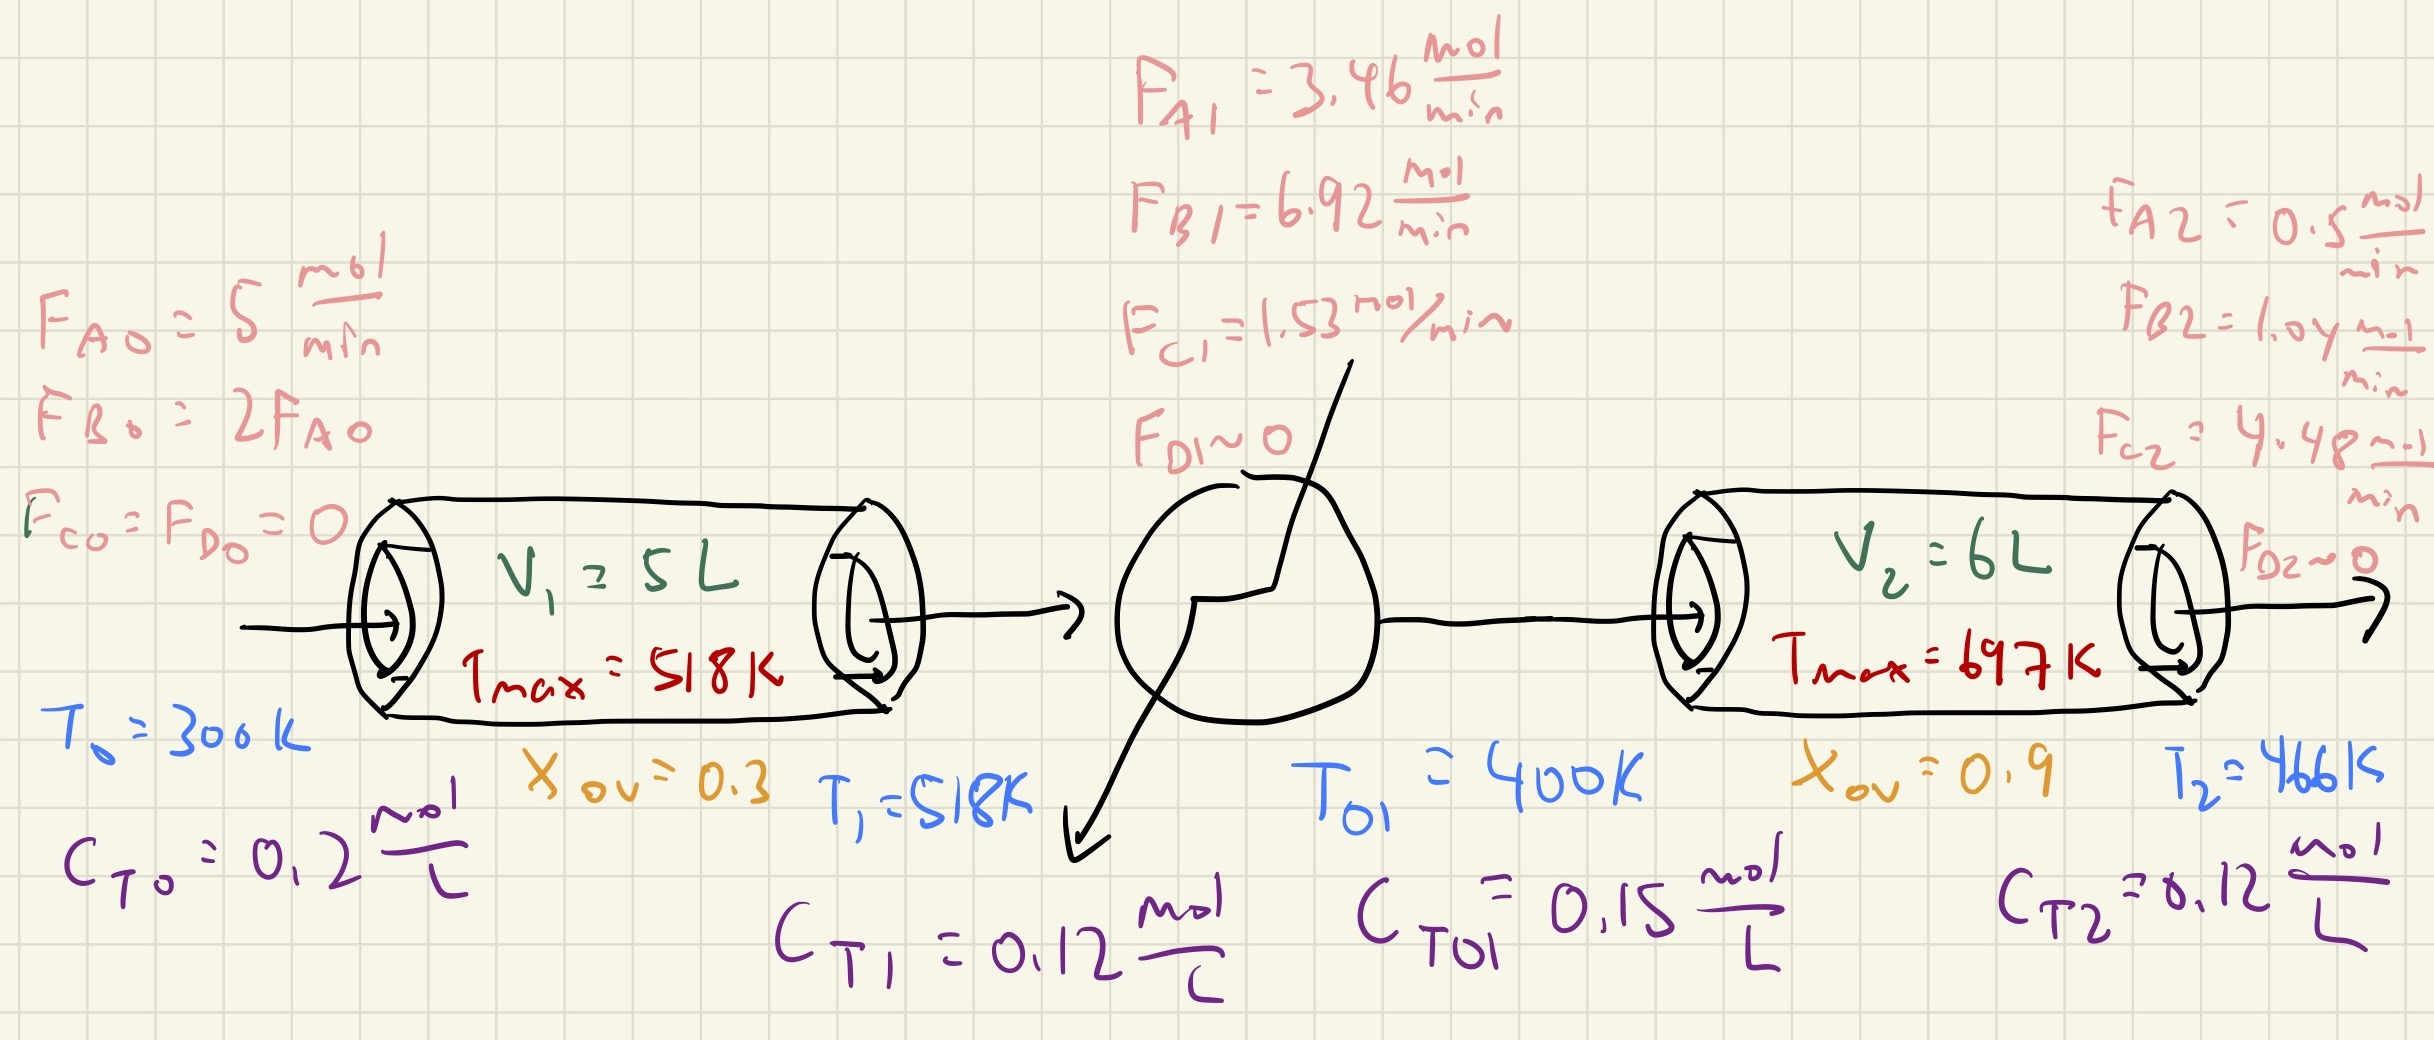

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Constants

In [ ]:
CPA, CPB, CPC, CPD, CPI = 0.010, 0.012, 0.014, 0.016, 0.00
H1B, H2A = -15, -10
H1A, H2C = H1B * 2, H2A * (2 / 3)

k1A0, T1A0, E1 = 40, 300, 8
k2C0, T2C0, E2 = 2, 300, 12

Fcool, CPcool, Ta0, Ua = 50, 0.010, 325, 0.080
R = 0.001986
CT0, T0, FA0 = 0.2, 300, 5

nu = np.array([[-1, -2, 1, 0], [-2/3, 0, -1, 1/3]])
Hrxn = np.array([H1A, H2C])
CP = np.array([CPA, CPB, CPC, CPD])
thetaB = 2
thetaI = 0
Ftot0 = FA0*(1 + thetaB + thetaI)
v0 = Ftot0 / CT0

## PFR design equations

In [ ]:
def PFR(V, y):
  F = y[:4]  # FA, FB, FC, FD
  T, Ta = y[4], y[5]
  Ftot = np.sum(F) + thetaI*FA0

  # Volumetric flowrate and concentrations
  v = v0 * (Ftot / Ftot0) * (T / T0)
  CA, CB, CC, _ = F / v

  # rate constants and reaction rates
  k1A = k1A0 * np.exp((E1 / R) * (1 / T1A0 - 1 / T))
  k2C = k2C0 * np.exp((E2 / R) * (1 / T2C0 - 1 / T))
  r = np.array([k1A * CA * CB**2, k2C * CA**2 * CC**3])

  # Balances
  rnet = np.dot(nu.T, r)
  Qg = np.dot(-Hrxn, r)
  Qr = Ua * (Ta - T)

  dTdV = (Qg + Qr) / (np.dot(F, CP) + thetaI*FA0*CPI)
  dTadV = -Qr / (Fcool * CPcool)

  return [*rnet, dTdV, dTadV]

## Extract information and plot

In [ ]:
def summarize(sol, label, initial_FA0):
  pfrvol = sol.t
  FA, FB, FC, FD, T, Ta = sol.y
  Ftot = FA + FB + FC + FD + thetaI*FA0
  v = v0 * (Ftot / Ftot0) * (T / T0)
  C = sol.y[:4] / v  # Matrix of concentrations [CA, CB, CC, CD]

  print(f"\n--- {label} RESULTS ---")
  print(f"Max T: {max(T):.2f} K")
  print(f"Outlet [FA, FB, FC, FD, T, Ta]: {sol.y[:, -1]}")
  print(f"Selectivity (S_C/D): {FC[-1] / FD[-1]:.4f}")
  print(f"Total Conversion (X): {(initial_FA0 - FA[-1]) / initial_FA0:.4f}")

  # Plot Concentrations
  plt.figure(figsize=(10, 4))
  plt.subplot(1, 2, 1)
  for i, name in enumerate(["CA", "CB", "CC", "CD"]):
      plt.plot(pfrvol, C[i], label=name)
  plt.xlabel("Reactor Volume (L)")
  plt.ylabel("Concentration (mol/L)")
  plt.legend()

  # Plot Temperatures
  plt.subplot(1, 2, 2)
  plt.plot(pfrvol, T, "r-", label="T")
  plt.plot(pfrvol, Ta, "b-", label="Ta")
  plt.xlabel("Reactor Volume (L)")
  plt.ylabel("Temperature (K)")
  plt.legend()
  plt.tight_layout()
  plt.show()

  return sol.y[:, -1]

## Simulate the reactors


=== REACTOR 1 INLET ===
Inlet conditions: [5.0, 10.0, 0.0, 0.0, 300.0, 325.0]

--- REACTOR 1 RESULTS ---
Max T: 518.34 K
Outlet [FA, FB, FC, FD, T, Ta]: [3.46023297e+00 6.92047367e+00 1.53975736e+00 1.93527133e-06
 5.18343954e+02 3.49781564e+02]
Selectivity (S_C/D): 795628.6697
Total Conversion (X): 0.3080


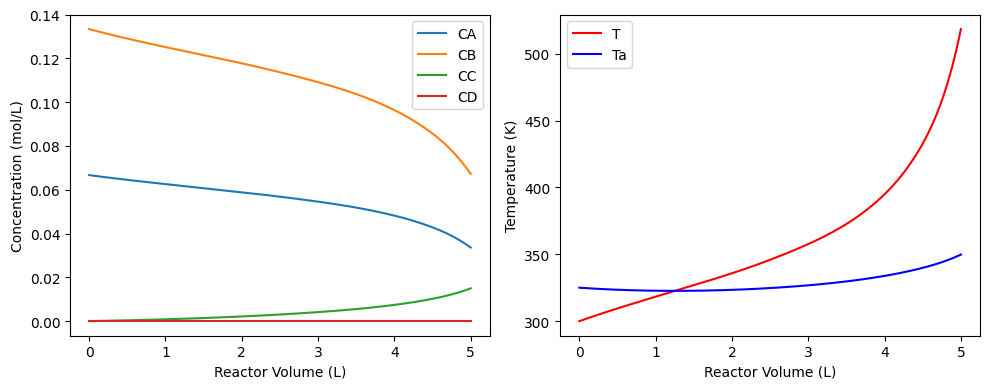


=== REACTOR 2 INLET ===
Inlet conditions: [3.460232966049025, 6.920473673183386, 1.5397573575943015, 1.9352713347070696e-06, 400.0, 325.0]

--- REACTOR 2 RESULTS ---
Max T: 697.17 K
Outlet [FA, FB, FC, FD, T, Ta]: [5.12951531e-01 1.03497866e+00 4.47570397e+00 2.26889924e-03
 4.92896049e+02 4.66372506e+02]
Selectivity (S_C/D): 1972.6323
Total Conversion (X): 0.8974


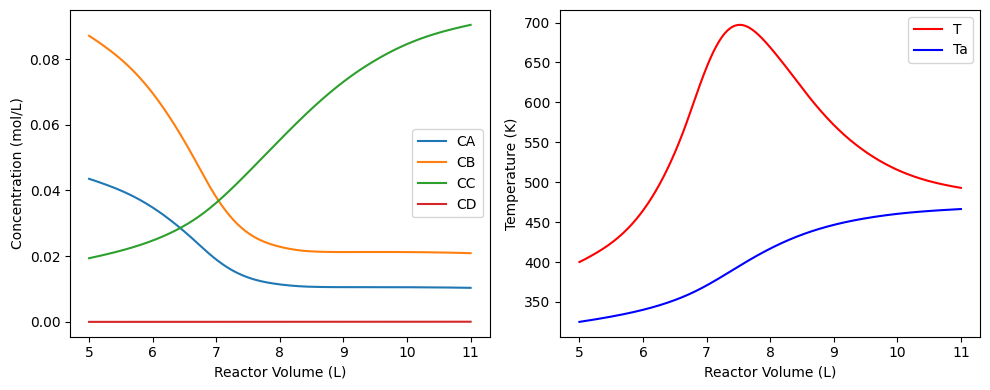

In [ ]:
def run_reactor(label, V_start, V_length, init_conds):
  V_span = [V_start, V_start + V_length]
  V_eval = np.linspace(*V_span, 400)

  print(f"\n=== {label} INLET ===")
  print("Inlet conditions:", [float(x) for x in init_conds])

  sol = solve_ivp(PFR, V_span, init_conds, t_eval=V_eval)
  return summarize(sol, label, FA0)

# Run Reactor 1
init_1 = [FA0, FA0 * 2, 0, 0, T0, Ta0]
outlet_1 = run_reactor("REACTOR 1", V_start=0, V_length=5, init_conds=init_1)

# Run Reactor 2 (With interstage cooling swap: T modified to 400K)
init_2 = [*outlet_1[:4], 400.0, 325.0] # take outlets from reactor 1 but reset T0 and Ta0
outlet_2 = run_reactor("REACTOR 2", V_start=5, V_length=6, init_conds=init_2)